<a href="https://colab.research.google.com/github/LebakulaSaanidhi/Fresh-or-rotten-fruit/blob/main/fresh_or_rotten_fruits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Define dataset parameters
data_dir = '/content/'
seed = 42
image_size = (180, 180) # Example size, adjust as needed
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

print("Training dataset created.")

Found 22 files belonging to 2 classes.
Using 18 files for training.
Training dataset created.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

print("Validation dataset created.")

Found 22 files belonging to 2 classes.
Using 4 files for validation.
Validation dataset created.


In [ ]:
class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Class names: ['Fresh_fruit', 'Rotten_fruit']
Number of classes: 2


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Datasets normalized.")

Datasets normalized.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets configured for performance.")

Datasets configured for performance.


In [ ]:
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
  ]
)

print("Data augmentation model defined.")

Data augmentation model defined.


In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

print("Data augmentation applied to the training dataset.")

Data augmentation applied to the training dataset.


In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(image_size[0], image_size[1], 3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

print("CNN model built successfully for 2 classes.")
model.summary()

CNN model built successfully for 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,300,770 (12.59 MB)

 Trainable params: 3,300,770 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
epochs = 15 # Increased epochs to allow for more learning
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print(f"Model training completed after {epochs} epochs.")

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 0.6932 - val_accuracy: 0.7500 - val_loss: 0.6906
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.5556 - loss: 0.6926 - val_accuracy: 0.7500 - val_loss: 0.6681
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.5556 - loss: 0.6887 - val_accuracy: 0.7500 - val_loss: 0.6266
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.5556 - loss: 0.6880 - val_accuracy: 0.7500 - val_loss: 0.6270
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.5556 - loss: 0.6874 - val_accuracy: 0.7500 - val_loss: 0.6446
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.5556 - loss: 0.6864 - val_accuracy: 0.7500 - val_loss: 0.6539
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.5556 - loss: 0.6865 - val_accuracy: 0.7500 - val_loss: 0.6505
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step - accuracy: 0.5556 - loss: 0.6857 - val_accuracy: 0.7500 - val_loss: 0.

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7500 - loss: 0.6329
Validation Loss: 0.6329
Validation Accuracy: 0.7500


In [ ]:
from sklearn.metrics import classification_report

print("classification_report imported successfully.")

classification_report imported successfully.


In [ ]:
import numpy as np

true_labels = []
predicted_labels = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_class_indices = np.argmax(predictions, axis=1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_class_indices)

print("True labels and predicted labels collected from validation dataset.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
True labels and predicted labels collected from validation dataset.


In [ ]:
print(classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0))
print("Classification report printed.")

              precision    recall  f1-score   support

 Fresh_fruit       0.00      0.00      0.00         1
Rotten_fruit       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

Classification report printed.


In [ ]:
test_image_paths = [
    '/content/test1.jpg',
    '/content/test2.jpg',
    '/content/test3.jpg',
    '/content/test4.jpg',
    '/content/test5.jpg'
]

print("Test image paths defined.")

Test image paths defined.


In [ ]:
predictions_list = []
print("Empty list 'predictions_list' initialized.")

Empty list 'predictions_list' initialized.


In [ ]:
import tensorflow as tf
import numpy as np

preprocessed_test_images = []

for img_path in test_image_paths:
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0 # Normalize pixel values
    preprocessed_test_images.append(img_array)

    # Make prediction
    prediction = model.predict(img_array)
    predictions_list.append(prediction)

print("Predictions for all test images generated and stored in 'predictions_list'.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predictions for all test images generated and stored in 'predictions_list'.


In [ ]:
print("\n--- Predictions for Test Images ---")
for i, prediction in enumerate(predictions_list):
    # Get the predicted class index (index with the highest probability)
    predicted_class_index = np.argmax(prediction)
    # Get the class name using the index
    predicted_class_name = class_names[predicted_class_index]
    # Get the confidence score for the predicted class
    confidence = prediction[0][predicted_class_index] * 100

    print(f"Image: {test_image_paths[i]}")
    print(f"Predicted Class: {predicted_class_name} (Confidence: {confidence:.2f}%)")
    print("----------------------------------")

print("Prediction display complete.")


--- Predictions for Test Images ---
Image: /content/test1.jpg
Predicted Class: Rotten_fruit (Confidence: 54.28%)
----------------------------------
Image: /content/test2.jpg
Predicted Class: Rotten_fruit (Confidence: 54.83%)
----------------------------------
Image: /content/test3.jpg
Predicted Class: Rotten_fruit (Confidence: 54.23%)
----------------------------------
Image: /content/test4.jpg
Predicted Class: Rotten_fruit (Confidence: 54.38%)
----------------------------------
Image: /content/test5.jpg
Predicted Class: Rotten_fruit (Confidence: 54.24%)
----------------------------------
Prediction display complete.


In [ ]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported as plt.")

matplotlib.pyplot imported as plt.


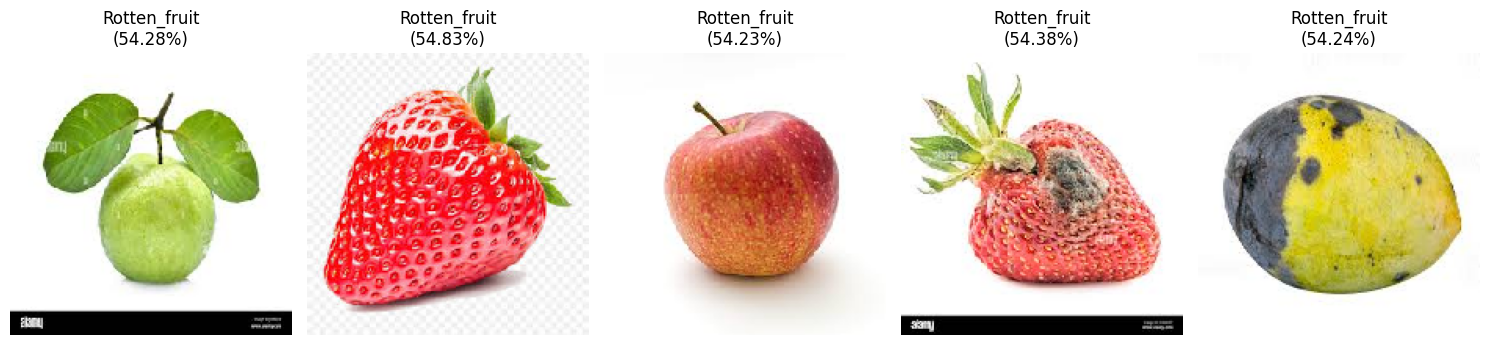

Test images displayed with their predicted classes and confidence scores.


In [ ]:
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(test_image_paths):
    # Load the image
    img = tf.keras.utils.load_img(img_path, target_size=image_size)

    # Get prediction details
    prediction = predictions_list[i]
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[0][predicted_class_index] * 100

    # Create a subplot
    plt.subplot(1, len(test_image_paths), i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class_name}\n({confidence:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Test images displayed with their predicted classes and confidence scores.")

In [ ]:
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())

print("Labels extracted from train_ds.")

Labels extracted from train_ds.


In [ ]:
from collections import Counter

label_counts = Counter(train_labels)

print("Class distribution in training dataset:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {label_counts[i]} images")

print("Class distribution analysis complete.")

Class distribution in training dataset:
  Fresh_fruit: 8 images
  Rotten_fruit: 10 images
Class distribution analysis complete.


In [ ]:
total_samples = sum(label_counts.values())
num_classes = len(class_names)

class_weights = {}
for i, count in label_counts.items():
    class_weights[i] = total_samples / (num_classes * count)

print("Calculated Class Weights:")
print(class_weights)


Calculated Class Weights:
{np.int32(1): 0.9, np.int32(0): 1.125}


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax') # Softmax for 2-class classification
])

print("CNN model rebuilt successfully for 2 classes.")
model.summary()

CNN model rebuilt successfully for 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,300,770 (12.59 MB)

 Trainable params: 3,300,770 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Model compiled successfully with class weights.")

Model compiled successfully with class weights.


In [ ]:
epochs = 15 # Keep the same number of epochs for comparison
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights
)

print(f"Model training completed after {epochs} epochs with class weights.")

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 0.6861 - val_accuracy: 0.2500 - val_loss: 1.0964
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.5000 - loss: 0.6923 - val_accuracy: 0.7500 - val_loss: 1.8811
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.5556 - loss: 3.3974 - val_accuracy: 0.7500 - val_loss: 0.7758
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.5556 - loss: 1.2674 - val_accuracy: 0.5000 - val_loss: 0.7945
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.5000 - loss: 0.6171 - val_accuracy: 0.2500 - val_loss: 1.2043
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.4444 - loss: 0.7658 - val_accuracy: 0.2500 - val_loss: 1.2311
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.4444 - loss: 0.7787 - val_accuracy: 0.2500 - val_loss: 1.0276
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.4444 - loss: 0.6912 - val_accuracy: 0.2500 - val_loss: 0.

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.9457
Validation Loss: 0.9457
Validation Accuracy: 0.5000


In [ ]:
true_labels = []
predicted_labels = []

print("Empty lists 'true_labels' and 'predicted_labels' initialized.")

Empty lists 'true_labels' and 'predicted_labels' initialized.


In [ ]:
import numpy as np

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_class_indices = np.argmax(predictions, axis=1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_class_indices)

print("True labels and predicted labels collected from validation dataset.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
True labels and predicted labels collected from validation dataset.


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0))
print("Classification report printed.")

              precision    recall  f1-score   support

 Fresh_fruit       0.00      0.00      0.00         1
Rotten_fruit       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4

Classification report printed.


In [ ]:
predictions_list = []

for img_path in test_image_paths:
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0 # Normalize pixel values

    # Make prediction using the weighted model
    prediction = model.predict(img_array)
    predictions_list.append(prediction)

print("Predictions for all test images generated and stored in 'predictions_list' using the weighted model.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions for all test images generated and stored in 'predictions_list' using the weighted model.


In [ ]:
preprocessed_test_images_batch = []

for img_path in test_image_paths:
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch dimension for each image
    img_array = img_array / 255.0 # Normalize pixel values
    preprocessed_test_images_batch.append(img_array)

# Concatenate all preprocessed images into a single batch for prediction
if preprocessed_test_images_batch:
    combined_test_batch = np.vstack(preprocessed_test_images_batch)
    predictions_list = model.predict(combined_test_batch)
else:
    predictions_list = []

print("Predictions for all test images generated and stored in 'predictions_list' using the weighted model.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predictions for all test images generated and stored in 'predictions_list' using the weighted model.


In [ ]:
print("\n--- Predictions for Test Images (Weighted Model) ---")
for i, prediction in enumerate(predictions_list):
    # Get the predicted class index (index with the highest probability)
    predicted_class_index = np.argmax(prediction)
    # Get the class name using the index
    predicted_class_name = class_names[predicted_class_index]
    # Get the confidence score for the predicted class
    confidence = prediction[predicted_class_index] * 100

    print(f"Image: {test_image_paths[i]}")
    print(f"Predicted Class: {predicted_class_name} (Confidence: {confidence:.2f}%)")
    print("----------------------------------")

print("Prediction display complete for weighted model.")


--- Predictions for Test Images (Weighted Model) ---
Image: /content/test1.jpg
Predicted Class: Rotten_fruit (Confidence: 66.02%)
----------------------------------
Image: /content/test2.jpg
Predicted Class: Fresh_fruit (Confidence: 98.91%)
----------------------------------
Image: /content/test3.jpg
Predicted Class: Fresh_fruit (Confidence: 67.18%)
----------------------------------
Image: /content/test4.jpg
Predicted Class: Fresh_fruit (Confidence: 65.88%)
----------------------------------
Image: /content/test5.jpg
Predicted Class: Fresh_fruit (Confidence: 56.68%)
----------------------------------
Prediction display complete for weighted model.


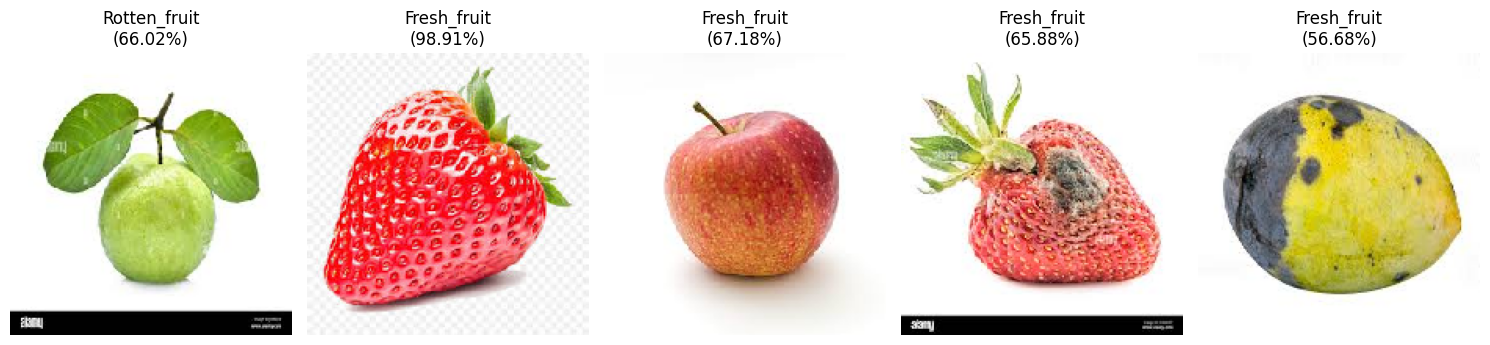

Test images displayed with their predicted classes and confidence scores from the weighted model.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(test_image_paths):
    # Load the image
    img = tf.keras.utils.load_img(img_path, target_size=image_size)

    # Get prediction details
    prediction = predictions_list[i]
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[predicted_class_index] * 100

    # Create a subplot
    plt.subplot(1, len(test_image_paths), i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class_name}\n({confidence:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Test images displayed with their predicted classes and confidence scores from the weighted model.")

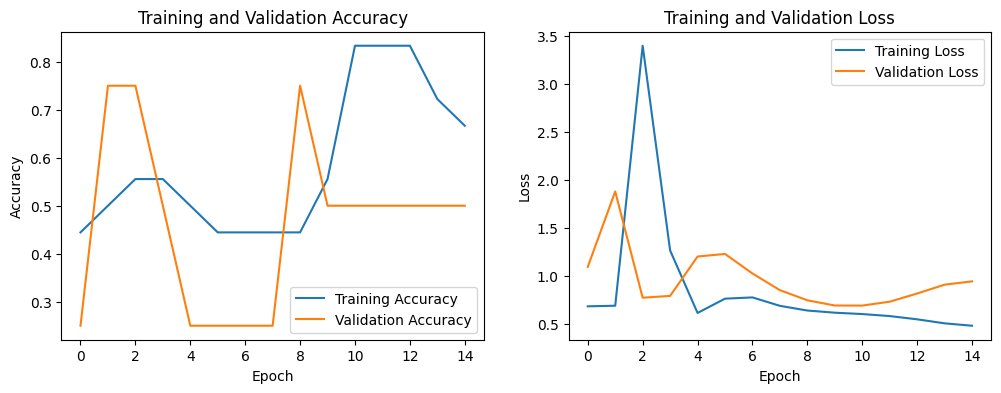

Training and validation accuracy/loss plots displayed.


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

print("Training and validation accuracy/loss plots displayed.")

In [ ]:
image_size = (224, 224) # Set image size to a standard MobileNetV2 input size

# Re-create training and validation datasets with the new image_size
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

# Re-apply normalization and prefetch
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Re-define data augmentation for the new image_size
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
  ]
)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

# 1. Import pre-trained MobileNetV2 base model
#    Exclude the top classification layer (include_top=False)
#    Specify the input_shape to match our image dimensions and channels
IMG_SHAPE = image_size + (3,) # Assuming image_size is (height, width)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# 2. Freeze the layers of the base model
base_model.trainable = False

# 3. Create a new Sequential model and add the frozen base model
#    Followed by a GlobalAveragePooling2D layer
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

# 4. Add Dense layers for classification
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax') # num_classes is 2

model_transfer = tf.keras.Sequential([
  base_model,
  global_average_layer,
  prediction_layer
])

print("Transfer learning model built successfully.")
model_transfer.summary()

Found 22 files belonging to 2 classes.
Using 18 files for training.
Found 22 files belonging to 2 classes.
Using 4 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Transfer learning model built successfully.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model_transfer.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Transfer learning model compiled successfully.")

Transfer learning model compiled successfully.


In [ ]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights
)

print(f"Transfer learning model training completed after {epochs} epochs with class weights.")

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6111 - loss: 0.8402 - val_accuracy: 0.5000 - val_loss: 0.7908
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - loss: 0.7148 - val_accuracy: 0.5000 - val_loss: 0.8241
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - accuracy: 0.5556 - loss: 0.6703 - val_accuracy: 0.5000 - val_loss: 0.8377
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step - accuracy: 0.6111 - loss: 0.5741 - val_accuracy: 0.5000 - val_loss: 0.8140
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step - accuracy: 0.9444 - loss: 0.3960 - val_accuracy: 0.5000 - val_loss: 0.7582
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step - accuracy: 0.8333 - loss: 0.4525 - val_accuracy: 0.5000 - val_loss: 0.6897
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.8333 - loss: 0.3633 - val_accuracy: 0.5000 - val_loss: 0.6364
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 1.0000 - loss: 0.2816 - val_accuracy: 0.5000 - val_loss: 0.590

In [ ]:
loss_transfer, accuracy_transfer = model_transfer.evaluate(val_ds)

print(f"Transfer Learning Validation Loss: {loss_transfer:.4f}")
print(f"Transfer Learning Validation Accuracy: {accuracy_transfer:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5000 - loss: 0.4799
Transfer Learning Validation Loss: 0.4799
Transfer Learning Validation Accuracy: 0.5000


In [ ]:
true_labels_transfer = []
predicted_labels_transfer = []

for images, labels in val_ds:
    predictions = model_transfer.predict(images)
    predicted_class_indices = np.argmax(predictions, axis=1)
    true_labels_transfer.extend(labels.numpy())
    predicted_labels_transfer.extend(predicted_class_indices)

print("True labels and predicted labels collected from validation dataset for transfer learning model.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
True labels and predicted labels collected from validation dataset for transfer learning model.


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_labels_transfer, predicted_labels_transfer, target_names=class_names, zero_division=0))
print("Classification report for transfer learning model printed.")

              precision    recall  f1-score   support

 Fresh_fruit       0.00      0.00      0.00         1
Rotten_fruit       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4

Classification report for transfer learning model printed.


In [ ]:
predictions_list_transfer = model_transfer.predict(combined_test_batch)

print("\n--- Predictions for Test Images (Transfer Learning Model) ---")
for i, prediction in enumerate(predictions_list_transfer):
    # Get the predicted class index (index with the highest probability)
    predicted_class_index = np.argmax(prediction)
    # Get the class name using the index
    predicted_class_name = class_names[predicted_class_index]
    # Get the confidence score for the predicted class
    confidence = prediction[predicted_class_index] * 100

    print(f"Image: {test_image_paths[i]}")
    print(f"Predicted Class: {predicted_class_name} (Confidence: {confidence:.2f}%)")
    print("----------------------------------")

print("Prediction display complete for transfer learning model.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step

--- Predictions for Test Images (Transfer Learning Model) ---
Image: /content/test1.jpg
Predicted Class: Rotten_fruit (Confidence: 76.85%)
----------------------------------
Image: /content/test2.jpg
Predicted Class: Fresh_fruit (Confidence: 99.77%)
----------------------------------
Image: /content/test3.jpg
Predicted Class: Fresh_fruit (Confidence: 58.17%)
----------------------------------
Image: /content/test4.jpg
Predicted Class: Rotten_fruit (Confidence: 86.07%)
----------------------------------
Image: /content/test5.jpg
Predicted Class: Rotten_fruit (Confidence: 99.82%)
----------------------------------
Prediction display complete for transfer learning model.


In [ ]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported as plt.")

matplotlib.pyplot imported as plt.


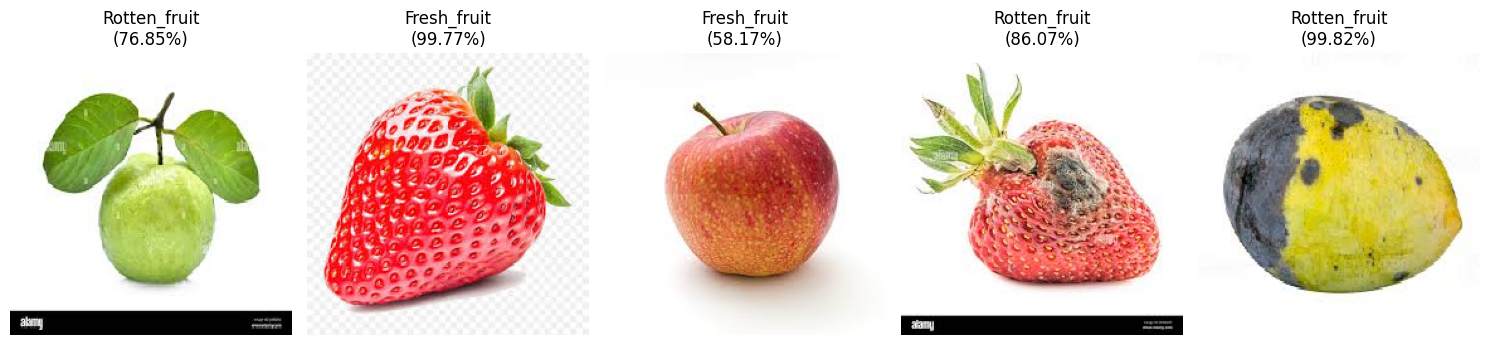

Test images displayed with their predicted classes and confidence scores from the transfer learning model.


In [ ]:
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(test_image_paths):
    # Load the image
    img = tf.keras.utils.load_img(img_path, target_size=image_size)

    # Get prediction details
    prediction = predictions_list_transfer[i]
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[predicted_class_index] * 100

    # Create a subplot
    plt.subplot(1, len(test_image_paths), i + 1)
    plt.imshow(img)
    plt.title(f"{predicted_class_name}\n({confidence:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Test images displayed with their predicted classes and confidence scores from the transfer learning model.")